# 1.2 Lattice-Gas Monte Carlo and Kinetic Monte Carlo

<!-- One H1 per notebook ("# <number> <Title>"): it sets the sidebar entry,
     breadcrumb, browser tab, and search result. The branded banner below is
     generated by the shared `ecp` package. -->

In [1]:
from ecp.style import header, use_style

use_style()
header(
    volume="Volume I — Statistical Mechanics & Monte Carlo",
    number="1.2",
    title="Lattice-Gas Monte Carlo and Kinetic Monte Carlo",
    blurb="Molecules adsorbed on a honeycomb substrate, simulated two ways: "
    "equilibrium Metropolis Monte Carlo for binding energies and cluster "
    "statistics — checked against exact enumeration and the ideal-gas limit — "
    "and the kinetic Monte Carlo (residence-time) algorithm that turns the same "
    "moves into real-time diffusion-limited growth.",
    difficulty="intermediate",
    estimate="90–120 min",
    source="FS 2023 · Lecture 2 (Monte Carlo)",
)

<ECP header: 2918 chars of HTML>

## Notebook overview

Where notebook 1.1 put a spin on every lattice site, here each site is either
*empty* or holds an *adsorbed molecule*, and the molecules attract their
neighbours: the **lattice gas**, the canonical model of adsorption,
wetting, and island growth on surfaces. We study it on a **honeycomb** lattice
(each site has three neighbours), the geometry of many molecular adlayers, and
we simulate it in two complementary ways.

First, **equilibrium Metropolis Monte Carlo**: the same accept/reject rule as in
1.1, used here to sample adsorbate configurations, measure how clustering grows
with the binding energy, and estimate a dimer binding energy from cluster
statistics. We pin the sampler down against an *exact enumeration* of a small
lattice and against the *ideal-gas* (non-interacting) limit, which has a
closed-form answer. Second, **kinetic Monte Carlo** (KMC): the residence-time
algorithm that advances *physical time* by sampling Poisson-distributed waiting
times, turning the model into a movie of diffusion-limited aggregation.

> **Provenance.** This notebook also develops **Lecture 2** (the foundations of
> Monte Carlo): **Dr. Carlo Pignedoli's** lattice-gas and kinetic-Monte-Carlo
> exercise, here redesigned and rephrased by the author, reimplemented cleanly,
> and restyled; the full course credit is in the footer.

> **Reading a validation.** Each exercise ends with a check against something
> independent: an exact enumeration, the ideal-gas combinatorics, the Poisson
> statistics the algorithm is built on. A ✗ is a prompt to locate a discrepancy
> (a real error, a convention, or Monte Carlo noise against a tight tolerance),
> not an automatic verdict; a ✓ is strong evidence, not proof.

> **Units and scope.** Energies (binding energy, barriers) and temperature are
> in the same arbitrary unit, so $k_B=1$ and $\beta=1/T$. This is a working
> review; for the methods see Newman & Barkema {cite}`newman-barkema`, Frenkel &
> Smit {cite}`frenkel-smit`, and, for kinetic Monte Carlo, Voter's primer
> {cite}`voter2007` and the original Bortz–Kalos–Lebowitz {cite}`bortz1975` and
> Gillespie {cite}`gillespie1977` algorithms.

## Theory in brief

### The lattice-gas model

Put an occupation variable $n_i\in\{0,1\}$ on every site $i$ of a honeycomb
lattice ($M=2L^2$ sites, coordination number $z=3$). Occupied nearest
neighbours lower the energy by the **binding energy** $\,d_e<0$:

```{math}
:label: eq-lg-energy
E = d_e\!\sum_{\langle i,j\rangle} n_i\,n_j ,
```

the sum running over nearest-neighbour bonds. The control parameters are the
binding energy $d_e$, the temperature $T$, and the **coverage**

```{math}
:label: eq-lg-coverage
\theta = \frac{N}{M}, \qquad N=\sum_i n_i .
```

(The lattice gas is exactly equivalent to the Ising model of 1.1 under
$n_i=(\sigma_i+1)/2$; we keep the occupation language because it matches the
physics of adsorption.)

### Sampling equilibrium: Metropolis Monte Carlo

To sample configurations with Boltzmann weight $P\propto e^{-\beta E}$ we reuse
the **Metropolis** rule from 1.1: propose a move, compute its energy change
$\Delta E$, and accept it with probability $\min(1,e^{-\beta\Delta E})$, which
satisfies detailed balance. The natural move for a fixed number of molecules is
to pick an occupied site and a random empty site and attempt to move the
molecule there; only the bonds at the old and new positions change, so $\Delta E$
is local. Metropolis samples *equilibrium*: it has no notion of time.

### Sampling dynamics: kinetic Monte Carlo

Real surface processes happen at *rates*. An activated event $k$ (a hop, a bond
formation) over a barrier $E_k$ occurs with an Arrhenius rate

```{math}
:label: eq-arrhenius
r_k = \nu\,e^{-\beta E_k},
```

$\nu$ an attempt frequency. The **kinetic Monte Carlo** (residence-time, or
Bortz–Kalos–Lebowitz) algorithm samples the *master equation* exactly: at each
step it lists every possible event with its rate, forms the total rate

```{math}
:label: eq-kmc-total
R = \sum_k r_k ,
```

picks one event with probability $r_k/R$, executes it, and advances the clock by
a waiting time drawn from the exponential (Poisson) distribution with mean
$1/R$,

```{math}
:label: eq-kmc-time
\Delta t = -\frac{\ln\rho}{R}, \qquad \rho\sim\mathcal{U}(0,1].
```

Unlike Metropolis, KMC produces a *trajectory in real time*: it is how one
simulates diffusion-limited growth, catalysis, and dewetting.

---
## Setup

The Setup below holds this notebook's data and instruments — nothing you are asked
to build. It is collapsed so the building stays yours; expand it whenever you want
the details.

<!-- setup-policy: v2 -->

In [2]:
import itertools

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

from ecp import validate

# data: one seeded generator for reproducibility.
rng = np.random.default_rng(0)

# data: series accents.
INK, AMBER, SOFT = "#16213e", "#c0851a", "#46506b"

# instrument: the lattice geometry below (neighbour lists, bond lists, drawing
# coordinates) is bookkeeping, not the lesson — the physics lives in what is put ON
# the lattice, not in enumerating its sites.


def honeycomb_neighbors(L):
    """Neighbour-index lists for a honeycomb lattice (z=3, bipartite, periodic).

    Parameters
    ----------
    L : int
        Linear size; the lattice has 2*L*L sites (two L×L sublattices A and B).

    Returns
    -------
    list of list of int
        For each site s = sub*L*L + i*L + j (sub 0=A, 1=B), the three
        nearest-neighbour site indices; A couples only to B and vice versa.
    """
    LL = L * L
    nbr = [None] * (2 * LL)
    A = lambda i, j: (i % L) * L + (j % L)
    B = lambda i, j: LL + (i % L) * L + (j % L)
    for i in range(L):
        for j in range(L):
            nbr[A(i, j)] = [B(i, j), B(i - 1, j), B(i, j - 1)]
            nbr[B(i, j)] = [A(i, j), A(i + 1, j), A(i, j + 1)]
    return nbr


def honeycomb_bonds(nbr):
    """Each nearest-neighbour bond listed once, from the A sublattice.

    Parameters
    ----------
    nbr : list of list of int
        Neighbour lists from ``honeycomb_neighbors``.

    Returns
    -------
    list of tuple of int
        The (a, b) site-index pairs, one per bond.
    """
    LL = len(nbr) // 2
    return [(a, b) for a in range(LL) for b in nbr[a]]


def site_positions(L):
    """Cartesian coordinates of every site, for plotting and animation.

    Parameters
    ----------
    L : int
        Linear lattice size.

    Returns
    -------
    tuple of numpy.ndarray
        The (x, y) coordinate arrays, each of length 2*L*L.
    """
    a1, a2, basis = (
        np.array([1.5, np.sqrt(3) / 2]),
        np.array([1.5, -np.sqrt(3) / 2]),
        np.array([1.0, 0.0]),
    )
    px, py = np.zeros(2 * L * L), np.zeros(2 * L * L)
    for i in range(L):
        for j in range(L):
            rA = i * a1 + j * a2
            px[i * L + j], py[i * L + j] = rA
            px[L * L + i * L + j], py[L * L + i * L + j] = rA + basis
    return px, py


def n_pairs(occ, bonds):
    """Number of occupied nearest-neighbour pairs.

    Parameters
    ----------
    occ : numpy.ndarray
        Per-site occupancy (0 empty, nonzero occupied).
    bonds : list of tuple of int
        Bond list from ``honeycomb_bonds``.

    Returns
    -------
    int
        Count of bonds whose two sites are both occupied.
    """
    return sum(1 for a, b in bonds if occ[a] and occ[b])


def cluster_sizes(mask, nbr):
    """Sizes of the connected components of the occupied sites.

    Parameters
    ----------
    mask : numpy.ndarray
        Boolean array marking occupied sites.
    nbr : list of list of int
        Neighbour lists from ``honeycomb_neighbors``.

    Returns
    -------
    numpy.ndarray
        The size of each connected occupied cluster (a single 0 if none).
    """
    sites = np.where(mask)[0]
    if sites.size == 0:
        return np.array([0])
    index = {s: i for i, s in enumerate(sites)}
    rows, cols = [], []
    for s in sites:
        for t in nbr[s]:
            if mask[t]:
                rows.append(index[s])
                cols.append(index[t])
    g = csr_matrix((np.ones(len(rows)), (rows, cols)), shape=(sites.size, sites.size))
    _, labels = connected_components(g, directed=False)
    return np.bincount(labels)

## Exercise 1 — The honeycomb lattice and the adsorbate model

Build the lattice and the two quantities every later exercise needs: the number
of occupied nearest-neighbour pairs and, through {eq}`eq-lg-energy`, the energy.
The schematic shows the geometry (two interleaved sublattices, each site bonded
to three neighbours) with one molecule and the three neighbours whose occupancy
sets its contribution to the energy.

**Part a)** Confirm the lattice is what it claims to be: every one of the
$2L^2$ sites has exactly three neighbours, the neighbour relation is symmetric
(if $i$ lists $j$ then $j$ lists $i$), and the lattice is bipartite, with the A
sublattice coupling only to B. Use `collections.Counter` over the neighbour lists
rather than a spot check — a lattice builder that is wrong at the periodic seam
is right almost everywhere.

**Part b)** Check the energy bookkeeping of {eq}`eq-lg-energy`: an isolated
molecule contributes no pairs, and one adjacent pair contributes exactly one bond
of energy $d_e$. Getting this wrong by a factor of two is the single most common
lattice-model error, because each bond is reachable from both of its ends.

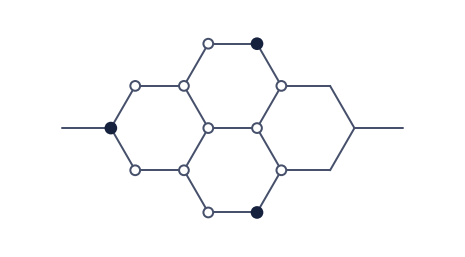

In [3]:
# (solution hidden on the public site)


### Validation 1 — the energy bookkeeping

Two molecules placed on adjacent sites must register exactly one occupied pair
(energy $d_e$); two molecules far apart must register none. This pins down
`n_pairs` and the meaning of {eq}`eq-lg-energy`.

In [4]:
nbr = honeycomb_neighbors(6)
bonds = honeycomb_bonds(nbr)
M = 2 * 6 * 6
adjacent = np.zeros(M, dtype=int)
adjacent[0] = 1
adjacent[nbr[0][0]] = 1  # site 0 and one of its neighbours
isolated = np.zeros(M, dtype=int)
isolated[0] = 1
isolated[nbr[nbr[0][0]][1]] = 1  # two sites two bonds apart
validate.check(
    n_pairs(adjacent, bonds) == 1
    and n_pairs(isolated, bonds) == 0
    and all(len(x) == 3 for x in nbr),
    "honeycomb has z=3 and the pair count is correct",
    f"adjacent→{n_pairs(adjacent, bonds)} pair, isolated→{n_pairs(isolated, bonds)} pairs",
)

✓  honeycomb has z=3 and the pair count is correct   [adjacent→1 pair, isolated→0 pairs]


True

## Exercise 2 — Equilibrium Metropolis Monte Carlo, checked by exact enumeration

A Metropolis move picks an occupied site and a random empty site and attempts to
move the molecule there, accepting with $\min(1,e^{-\beta\Delta E})$ where
$\Delta E$ counts only the bonds gained and lost. The cleanest possible test is a
lattice small enough to solve *exactly*: for $L=2$ ($M=8$ sites) with $N=3$
molecules there are only $\binom{8}{3}=56$ configurations, so the Boltzmann
average $\langle E\rangle$ can be summed directly. A correct sampler must
reproduce it.

**Part a)** Implement `metropolis_sweep(occ, occupied, nbr, de, beta, n_moves)`,
proposing `n_moves` single-molecule hops to a random empty site and accepting each
with probability $\min(1, e^{-\beta\Delta E})$. Compute $\Delta E$ from the change
in pair count *local to the move* — the moved molecule's old and new neighbours —
never by re-evaluating the whole lattice, which would turn an $O(z)$ update into
an $O(N)$ one.
**Write this one yourself** — the implementation is the lesson.

**Part b)** Run it on the $L=2$ lattice and compare $\langle E\rangle$ with the
exact enumeration over all $\binom{8}{N}$ configurations. At this size the exact
answer is available, which is the only reason the sampler can be *proved* right
rather than merely made plausible.

In [5]:
# (solution hidden on the public site)


In [6]:
# (solution hidden on the public site)


### Validation 2 — sampler vs. exact enumeration

The Monte Carlo average energy must match the exact Boltzmann sum on the small
lattice: the decisive check that the move samples the correct ensemble.

In [7]:
validate.close(E_mc, E_exact, "MC ⟨E⟩ matches exact enumeration (L=2, N=3)", rtol=0.05)

✓  MC ⟨E⟩ matches exact enumeration (L=2, N=3)   [got -0.08392 vs expected -0.0837896 (rtol=0.05, atol=1e-09)]


True

## Exercise 3 — The ideal lattice gas ($d_e=0$)

Switch off the interaction. With $d_e=0$ every configuration is equally likely,
so the molecules are placed at random and the expected number of occupied
nearest-neighbour pairs is a pure combinatorial fact: each of the $N_{\rm bonds}$
bonds is occupied at both ends with probability $\binom{M-2}{N-2}/\binom{M}{N}$,
giving

```{math}
:label: eq-ideal-pairs
\langle N_{\rm pairs}\rangle_{0} = N_{\rm bonds}\,\frac{N(N-1)}{M(M-1)} .
```

This non-interacting baseline $\langle N_{\rm pairs}\rangle_0$ is exactly the
reference we need for the binding-energy estimate in the next exercise.

**Part a)** Run the sampler at $d_e = 0$, where the molecules are
non-interacting and every arrangement of $N$ molecules on $2L^2$ sites is equally
likely.

**Part b)** Compare the measured mean pair count with the combinatorial
prediction {eq}`eq-ideal-pairs`. This is a check on the *sampler*, not on the
physics: at $d_e = 0$ the answer is pure counting, so any disagreement indicts the
Metropolis implementation rather than the model.

In [8]:
# (solution hidden on the public site)


### Validation 3 — the ideal-gas combinatorics

With no interaction the measured pair count must equal the random-placement
prediction {eq}`eq-ideal-pairs`, the sampler reproducing the analytic
ideal-gas limit.

In [9]:
validate.close(
    pairs_ideal_mc,
    pairs_ideal_formula,
    "d_e=0 pair count matches the ideal-gas combinatorics",
    rtol=0.05,
)

✓  d_e=0 pair count matches the ideal-gas combinatorics   [got 1.90067 vs expected 1.90141 (rtol=0.05, atol=1e-09)]


True

## Exercise 4 — Binding energy, clustering, and a dimer binding-energy estimate

Turn the interaction back on. As $d_e$ becomes more negative, attraction pulls
molecules together and the number of occupied pairs grows, the lattice gas
*clusters*. This is the basis of a classic experimental trick: measure the
dimer concentration $n$ in the interacting system and the non-interacting
baseline $n_0$ ({eq}`eq-ideal-pairs`), and invert the dilute-limit
law-of-mass-action relation $n/n_0\sim e^{-\beta d_e}$ to read off the binding
energy,

```{math}
:label: eq-dimer-estimate
d_e \approx k_B T\,\ln\!\frac{n_0}{n} .
```

We test the whole chain by a **round trip**: choose a true $d_e$, simulate to
get $n$, take $n_0$ from $d_e=0$, and check that {eq}`eq-dimer-estimate`
recovers $d_e$. It is only a *rough* estimate (the dilute-limit derivation drops
correlations), so we expect the right sign and order of magnitude, not three
digits. The animation shows molecules diffusing and aggregating as the sampler
equilibrates.

**Part a)** Scan the binding energy $d_e$ and show the mean pair count rising as
the interaction is turned on — clustering, measured rather than asserted.

**Part b)** Invert the measurement: form the dimer estimate
{eq}`eq-dimer-estimate` from the observed pair counts and compare it with the
$d_e$ that was fed in. A round trip through the model that returns its own input
is a far stronger statement than a monotonic trend.

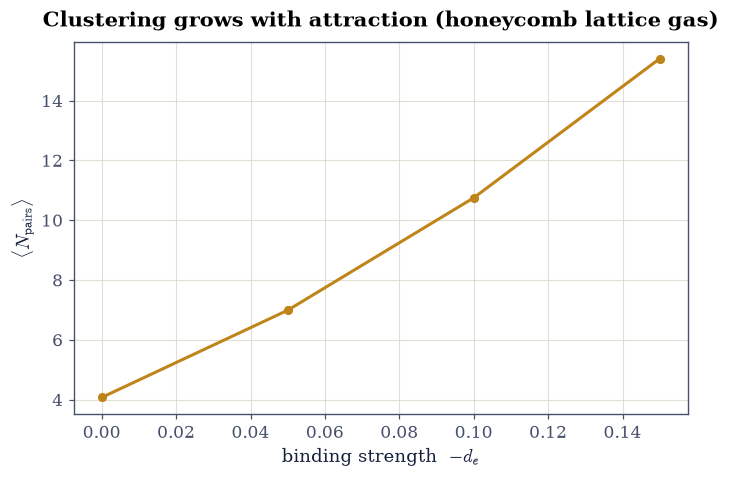

In [10]:
# (solution hidden on the public site)


### Validation 4 — clustering trend and the binding-energy round trip

Two checks: the pair count must increase monotonically as the attraction
strengthens, and the rough estimate {eq}`eq-dimer-estimate` must recover the
input $d_e$ to within a factor of two (right sign and order of magnitude).

In [11]:
validate.check(
    bool(np.all(np.diff(pairs_scan) > 0)),
    "clustering grows monotonically as binding strengthens",
    f"⟨pairs⟩ at d_e={list(de_scan)} → {np.round(pairs_scan, 1).tolist()}",
)
validate.check(
    de_estimate < 0 and 0.4 < de_estimate / de_true < 2.5,
    "kT·ln(n0/n) recovers the binding energy to within a factor of ~2",
    f"d_e(true)={de_true:+.3f}, estimate={de_estimate:+.3f}",
)

✓  clustering grows monotonically as binding strengthens   [⟨pairs⟩ at d_e=[np.float64(0.0), np.float64(-0.05), np.float64(-0.1), np.float64(-0.15)] → [4.1, 7.0, 10.7, 15.4]]
✓  kT·ln(n0/n) recovers the binding energy to within a factor of ~2   [d_e(true)=-0.100, estimate=-0.058]


True

### Watching the lattice gas equilibrate

Starting from a random placement at a clustering binding energy, the Metropolis
dynamics pull the molecules into compact islands as the run proceeds.

In [12]:
# (solution hidden on the public site)


## Exercise 5 — Kinetic Monte Carlo: the residence-time algorithm

Metropolis told us *where* equilibrium sits; KMC tells us *how fast* the system
gets there. The algorithm rests on two statistical guarantees, and we verify
both directly. Given a catalogue of events with rates $r_k$ and total rate $R$
({eq}`eq-kmc-total`): (i) each step advances physical time by an
**exponentially distributed** waiting time of mean $1/R$ ({eq}`eq-kmc-time`),
so $\langle\Delta t\rangle=1/R$ and, for an exponential law, the standard
deviation equals the mean; (ii) the executed event is chosen with probability
**proportional to its rate**, $r_k/R$.

**Part a)** Draw many waiting times for a fixed total rate $R$ using
{eq}`eq-kmc-time`, and check both the mean and the spread against the exponential
distribution: $\langle\Delta t\rangle = 1/R$ and $\sigma_{\Delta t} = 1/R$ too.
The standard deviation equalling the mean is the signature of a Poisson process,
and checking only the mean would miss a wrong distribution with the right average.
**Write this one yourself** — the implementation is the lesson.

**Part b)** Select many events from a fixed rate catalogue and confirm the
selection frequencies track the rates in proportion. Together the two parts are
the algorithm's whole correctness claim: *when* the next event happens, and
*which* one it is.

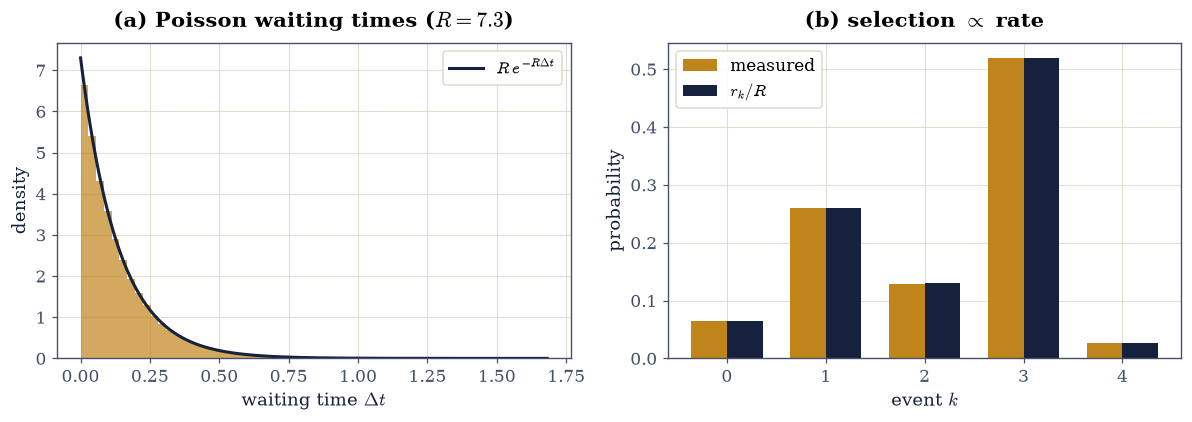

In [13]:
# (solution hidden on the public site)


### Validation 5 — the two guarantees of the algorithm

The waiting-time mean and standard deviation must both equal $1/R$ (the
exponential signature), and the event frequencies must match $r_k/R$.

In [14]:
validate.close(
    dt_samples.mean(), 1 / R_demo, "KMC waiting-time mean equals 1/R", rtol=0.02
)
validate.close(
    dt_samples.std(),
    1 / R_demo,
    "KMC waiting time is exponential (std = mean)",
    rtol=0.03,
)
validate.close(
    freq,
    rates_demo / rates_demo.sum(),
    "KMC selects events with frequency proportional to rate",
    rtol=0.03,
    atol=0.003,
)

✓  KMC waiting-time mean equals 1/R   [got 0.136917 vs expected 0.136986 (rtol=0.02, atol=1e-09)]
✓  KMC waiting time is exponential (std = mean)   [got 0.137384 vs expected 0.136986 (rtol=0.03, atol=1e-09)]
✓  KMC selects events with frequency proportional to rate   [max|Δ| = 0.00059974 (rtol=0.03, atol=0.003)]


True

## Exercise 6 — Diffusion-limited growth

Now run the algorithm. Molecules start mobile and randomly placed; each mobile
molecule can **diffuse** to an empty neighbour at rate $r_d=\nu e^{-\beta E_d}$
or, if it touches another molecule, **bind** irreversibly at rate
$r_b=\nu e^{-\beta E_b}$ ({eq}`eq-arrhenius`). The clock advances by
{eq}`eq-kmc-time` after every event. From a well-mixed start the molecules
diffuse, meet, and freeze into growing clusters: diffusion-limited aggregation,
played out in real time.

**Part a)** Implement `kmc_step(occ, nbr, r_d, r_b)`: build the rate catalogue
for the current configuration, draw the waiting time from {eq}`eq-kmc-time`,
select an event with the residence-time rule of Exercise 5, and execute it.
Every step advances physical time by a *different* amount — that is the whole
difference between kinetic Monte Carlo and the Metropolis sweeps of Exercise 2,
whose steps carry no time at all.
**Write this one yourself** — the implementation is the lesson.

**Part b)** Run it from a random start, recording snapshots, and confirm that
aggregation has occurred: the mean cluster size must rise well above the
random-start baseline. Compare against that baseline rather than against zero,
since a random configuration already contains adjacent pairs by chance.

In [15]:
# (solution hidden on the public site)


In [16]:
# (solution hidden on the public site)


### Validation 6 — aggregation has occurred

Diffusion-limited growth must turn the well-mixed start (clusters of size ≈ 1–2)
into substantially larger aggregates: the mean cluster size must exceed the
random baseline by a clear margin.

In [17]:
validate.check(
    final_sizes.mean() > 1.5 * init_sizes.mean(),
    "KMC growth aggregates the gas into larger clusters",
    f"mean cluster size {init_sizes.mean():.2f} → {final_sizes.mean():.2f}, "
    f"largest = {final_sizes.max()}, elapsed t = {t_elapsed:.1f}",
)

✓  KMC growth aggregates the gas into larger clusters   [mean cluster size 1.66 → 2.90, largest = 11, elapsed t = 65.9]


True

## Notebook summary

We mapped adsorption onto a honeycomb lattice gas and studied it two complementary
ways. Equilibrium Metropolis Monte Carlo reproduced the exact enumerated
$\langle E\rangle$ for small systems and, with an attractive nearest-neighbour
interaction, drove clustering beyond the ideal-gas coverage. Kinetic Monte Carlo,
through the residence-time (BKL) algorithm, then advanced the same model in real
time from its rate constants, producing diffusion-limited growth. The contrast is
the lesson: the equilibrium and kinetic pictures answer different questions (the
final structure versus the pathway and timescale that reach it) from one set of
energetics.

## Outlook

- **Dendritic vs. compact morphology.** Whether diffusion-limited growth yields
  ramified (dendritic) or compact islands is set by the *ratio* of binding to
  edge-diffusion rates. Capturing the crossover quantitatively needs a
  **coordination-dependent diffusion barrier** (a molecule with more bonds is
  harder to move, $E_d\to E_d + k\,\Delta$ for $k$ occupied neighbours), so that
  slow binding lets molecules edge-diffuse into high-coordination pockets before
  freezing. Add that term and watch the islands compact as $E_b$ rises above
  $E_d$.
- **Reversible binding.** Give the bound state a finite unbinding rate obeying
  detailed balance; the growth then *anneals* toward the equilibrium islands of
  Exercise 4, connecting the kinetic and equilibrium pictures.
- **Rejection-free efficiency.** The event list here is rebuilt each step; the
  Bortz–Kalos–Lebowitz {cite}`bortz1975` and binning strategies update it
  incrementally for large lattices.
- **Real time scales.** Restoring physical attempt frequencies $\nu\sim10^{12}\,
  \mathrm{s^{-1}}$ in {eq}`eq-arrhenius` turns the dimensionless clock into
  seconds, letting KMC bridge to experimental deposition rates.

### References

```{bibliography}
:filter: docname in docnames
```

In [18]:
from ecp.style import footer

footer()

<ECP header: 1690 chars of HTML>